# Brain Tumor Classification with Logic Tensor Networks

This notebook demonstrates:
1. Loading a binary image classification dataset (brain tumor MRI images)
2. Using OpenAI Vision API to extract tags from images
3. Converting images to tabular data using boolean features
4. Creating logical rules for classification
5. Training Logic Tensor Networks (LTN) with the extracted features and rules

## Setup and Imports

In [1]:
import os
import json
import base64
import time
from pathlib import Path
from typing import List, Dict, Tuple
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
from tqdm import tqdm

# Load environment variables
from dotenv import load_dotenv

# OpenAI
from openai import OpenAI, RateLimitError, APIError

# TensorFlow and LTN
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import ltn

# Set random seeds for reproducibility
np.random.seed(99)
tf.random.set_seed(99)

2026-01-28 00:41:23.023664: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-28 00:41:23.043375: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-28 00:41:23.049715: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-28 00:41:23.064736: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-28 00:41:24.218909: W tensorflow/compiler/tf2

## Configuration

In [2]:
# Load environment variables from secrets.env
load_dotenv('../secrets.env')

# Paths - Updated to use input/brain_tumor_images
DATA_DIR = Path("../input/brain_tumor_images")
TUMOR_DIR = DATA_DIR / "yes"
NO_TUMOR_DIR = DATA_DIR / "no"
CACHE_FILE = DATA_DIR / "tags_cache.json"

# OpenAI API
# Reads OPENAI_API_KEY from secrets.env
api_key = os.getenv("OPENAI_API_KEY")
if not api_key:
    raise ValueError("OPENAI_API_KEY not found in secrets.env file")
client = OpenAI(api_key=api_key)

# Training parameters
TEST_SIZE = 0.3
RANDOM_STATE = 42

## 1. Load Image Dataset

In [3]:
def load_image_paths() -> Tuple[List[Path], List[int]]:
    """
    Load image paths and labels from the dataset.
    Returns:
        image_paths: List of Path objects
        labels: List of binary labels (1 = tumor, 0 = no tumor)
    """
    image_paths = []
    labels = []
    
    # Load tumor images (label = 1)
    for img_path in TUMOR_DIR.glob("*.[jJ][pP][gG]"):
        image_paths.append(img_path)
        labels.append(1)
    
    for img_path in TUMOR_DIR.glob("*.[jJ][pP][eE][gG]"):
        image_paths.append(img_path)
        labels.append(1)
    
    # Load no tumor images (label = 0)
    for img_path in NO_TUMOR_DIR.glob("*.[jJ][pP][gG]"):
        image_paths.append(img_path)
        labels.append(0)
    
    for img_path in NO_TUMOR_DIR.glob("*.[jJ][pP][eE][gG]"):
        image_paths.append(img_path)
        labels.append(0)
    
    print(f"Loaded {len(image_paths)} images")
    print(f"  - Tumor: {sum(labels)} images")
    print(f"  - No tumor: {len(labels) - sum(labels)} images")
    
    return image_paths, labels

image_paths, labels = load_image_paths()

Loaded 251 images
  - Tumor: 154 images
  - No tumor: 97 images


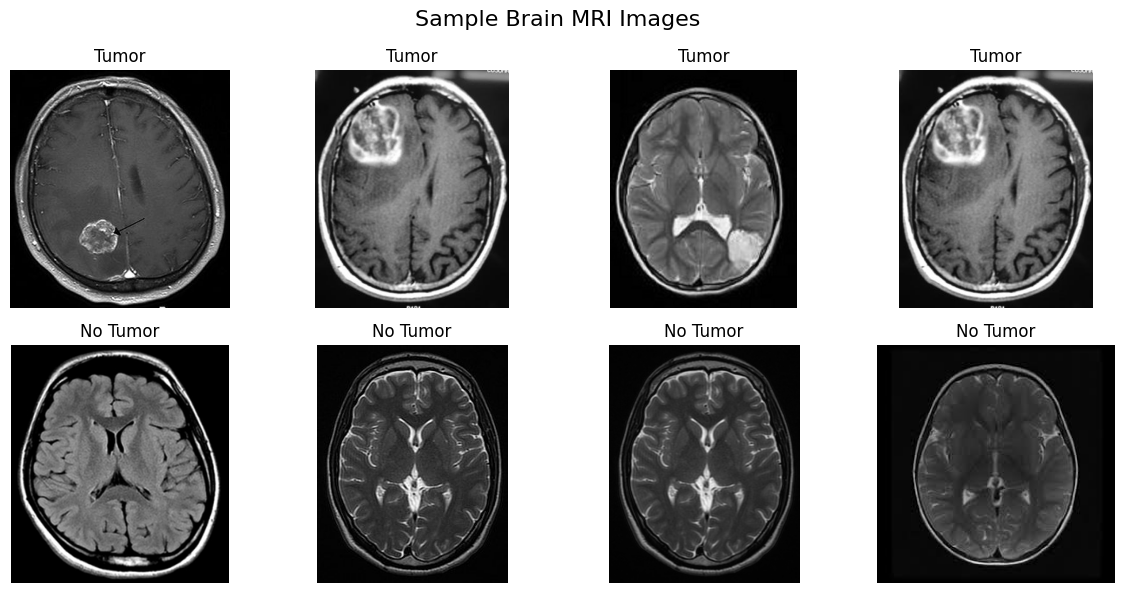

In [4]:
# Visualize some sample images
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
fig.suptitle('Sample Brain MRI Images', fontsize=16)

# Show 4 tumor images
tumor_indices = [i for i, label in enumerate(labels) if label == 1][:4]
for idx, ax in enumerate(axes[0]):
    img = Image.open(image_paths[tumor_indices[idx]])
    ax.imshow(img, cmap='gray')
    ax.set_title('Tumor')
    ax.axis('off')

# Show 4 no tumor images
no_tumor_indices = [i for i, label in enumerate(labels) if label == 0][:4]
for idx, ax in enumerate(axes[1]):
    img = Image.open(image_paths[no_tumor_indices[idx]])
    ax.imshow(img, cmap='gray')
    ax.set_title('No Tumor')
    ax.axis('off')

plt.tight_layout()
plt.show()

## 2. Extract Tags using OpenAI Vision API

In [5]:
def encode_image_to_base64(image_path: Path) -> str:
    """Encode image to base64 string."""
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode('utf-8')

def extract_tags_from_image(image_path: Path, max_retries: int = 5) -> List[str]:
    """
    Use OpenAI Vision API to extract descriptive tags from an MRI image.
    Includes retry logic with exponential backoff for rate limit handling.
    """
    base64_image = encode_image_to_base64(image_path)
    
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model="gpt-4o-mini",
                messages=[
                    {
                        "role": "user",
                        "content": [
                            {
                                "type": "text",
                                "text": """Analyze this brain MRI scan and provide a list of visual features and characteristics you observe. 
Focus on medical/anatomical features such as:
- Presence or absence of abnormal masses
- Brightness/darkness patterns
- Symmetry or asymmetry
- Texture characteristics (smooth, rough, irregular)
- Contrast levels
- Size variations
- Shape irregularities
- Any visible lesions or abnormalities

Return ONLY a comma-separated list of descriptive tags, like: "bright_region, asymmetric, irregular_mass, high_contrast"
Use lowercase and underscores for multi-word tags."""
                            },
                            {
                                "type": "image_url",
                                "image_url": {
                                    "url": f"data:image/jpeg;base64,{base64_image}"
                                }
                            }
                        ]
                    }
                ],
                max_tokens=300
            )
            
            tags_str = response.choices[0].message.content.strip()
            tags = [tag.strip() for tag in tags_str.split(',')]
            
            # Small delay between successful requests to avoid hitting rate limits
            time.sleep(0.5)
            
            return tags
            
        except RateLimitError as e:
            # Rate limit hit - use exponential backoff
            wait_time = (2 ** attempt) + (0.5 * attempt)  # Exponential backoff
            print(f"Rate limit hit for {image_path.name}. Waiting {wait_time:.1f}s (attempt {attempt + 1}/{max_retries})...")
            time.sleep(wait_time)
            
            if attempt == max_retries - 1:
                print(f"Failed after {max_retries} attempts: {e}")
                return []
                
        except APIError as e:
            # API error - retry with shorter backoff
            wait_time = 2 * (attempt + 1)
            print(f"API error for {image_path.name}. Waiting {wait_time}s (attempt {attempt + 1}/{max_retries})...")
            time.sleep(wait_time)
            
            if attempt == max_retries - 1:
                print(f"Failed after {max_retries} attempts: {e}")
                return []
                
        except Exception as e:
            print(f"Error processing {image_path}: {e}")
            return []
    
    return []

## 3. Tag Caching System

### Rate Limiting Strategy

The tag extraction includes multiple safeguards against OpenAI API rate limits:

1. **Exponential Backoff**: If a rate limit error occurs, the system automatically retries with increasing delays (1s, 2s, 4s, 8s, 16s)
2. **Per-Request Delay**: 0.5s delay after each successful request
3. **Configurable Inter-Request Delay**: Additional configurable delay between images (default: 1.0s)
4. **Automatic Caching**: Progress is saved after each image, so interrupted runs can resume
5. **Max Retries**: Up to 5 attempts per image before giving up

You can adjust `delay_between_requests` if you experience rate limits (e.g., set to 2.0 or 3.0 for slower but safer processing).

In [6]:
def load_tags_cache() -> Dict[str, List[str]]:
    """Load cached tags from JSON file."""
    if CACHE_FILE.exists():
        with open(CACHE_FILE, 'r') as f:
            return json.load(f)
    return {}

def save_tags_cache(cache: Dict[str, List[str]]):
    """Save tags cache to JSON file."""
    with open(CACHE_FILE, 'w') as f:
        json.dump(cache, f, indent=2)

def extract_and_cache_tags(image_paths: List[Path], force_refresh: bool = False, 
                           delay_between_requests: float = 1.0) -> Dict[str, List[str]]:
    """
    Extract tags for all images with caching and rate limit protection.
    
    Args:
        image_paths: List of image paths to process
        force_refresh: If True, re-extract all tags ignoring cache
        delay_between_requests: Delay in seconds between API requests (default: 1.0)
    """
    cache = {} if force_refresh else load_tags_cache()
    
    images_to_process = []
    for img_path in image_paths:
        img_key = str(img_path.relative_to(DATA_DIR))
        if img_key not in cache:
            images_to_process.append((img_path, img_key))
    
    if images_to_process:
        print(f"Processing {len(images_to_process)} images (delay: {delay_between_requests}s between requests)")
    
    for img_path, img_key in tqdm(images_to_process, desc="Extracting tags"):
        tags = extract_tags_from_image(img_path)
        cache[img_key] = tags
        
        # Save after each image to avoid losing progress
        save_tags_cache(cache)
        
        # Additional delay between requests (on top of the one in extract_tags_from_image)
        if delay_between_requests > 0:
            time.sleep(delay_between_requests)
    
    return cache

In [7]:
import re

def is_valid_tag(tag: str) -> bool:
    """
    Check if a tag is a valid feature tag (not a conversational response).
    
    Valid tags are:
    - Short (< 50 chars)
    - Lowercase with underscores (e.g., "abnormal_mass", "high_contrast")
    - Don't start with conversational patterns like "I ", "I'", "Please", etc.
    """
    tag = tag.strip()
    
    # Too long - likely a sentence
    if len(tag) > 50:
        return False
    
    # Empty
    if len(tag) == 0:
        return False
    
    # Starts with conversational patterns
    conversational_starts = [
        "I ", "I'", "I'm", "Please", "However", "If you", "Let me",
        "feel free", "you can", "including", "based on"
    ]
    for pattern in conversational_starts:
        if tag.lower().startswith(pattern.lower()):
            return False
    
    # Contains conversational markers
    conversational_markers = [
        "can help", "assist", "analyze", "interpret", "consult",
        "medical professional", "let me know", "questions", "description"
    ]
    tag_lower = tag.lower()
    for marker in conversational_markers:
        if marker in tag_lower:
            return False
    
    # Valid tags should primarily be lowercase with underscores
    # Allow some flexibility but reject if too many uppercase or special chars
    valid_pattern = re.compile(r'^[a-z][a-z0-9_]*$')
    if valid_pattern.match(tag):
        return True
    
    # Also accept tags with minor variations (e.g., "high-contrast" or trailing quotes)
    cleaned = tag.lower().replace('-', '_').replace('"', '').replace("'", '').strip()
    if valid_pattern.match(cleaned):
        return True
    
    return False


def filter_tags_cache(tags_cache: Dict[str, List[str]]) -> Dict[str, List[str]]:
    """
    Filter the tags cache to keep only valid feature tags.
    """
    filtered_cache = {}
    total_before = 0
    total_after = 0
    
    for img_key, tags in tags_cache.items():
        total_before += len(tags)
        valid_tags = [tag for tag in tags if is_valid_tag(tag)]
        # Also normalize: lowercase, replace hyphens with underscores
        normalized_tags = [tag.lower().replace('-', '_').replace('"', '').strip() 
                          for tag in valid_tags]
        filtered_cache[img_key] = normalized_tags
        total_after += len(normalized_tags)
    
    print(f"Tag filtering: {total_before} -> {total_after} tags ({total_before - total_after} removed)")
    return filtered_cache


# Test the filter on some examples
test_tags = [
    "abnormal_mass",  # Valid
    "high_contrast",  # Valid
    "I can't analyze images directly",  # Invalid - conversational
    "Please consult a medical professional",  # Invalid - conversational
    "feel free to ask!",  # Invalid - conversational
    "irregular_shape",  # Valid
    "I'm unable to analyze",  # Invalid - conversational
]

print("Tag validation test:")
for tag in test_tags:
    print(f"  '{tag}': {'✓ Valid' if is_valid_tag(tag) else '✗ Invalid'}")

Tag validation test:
  'abnormal_mass': ✓ Valid
  'high_contrast': ✓ Valid
  'I can't analyze images directly': ✗ Invalid
  'Please consult a medical professional': ✗ Invalid
  'feel free to ask!': ✗ Invalid
  'irregular_shape': ✓ Valid
  'I'm unable to analyze': ✗ Invalid


In [8]:
# Extract tags for all images (this will use cache if available)
# Set force_refresh=True to re-extract all tags
# Adjust delay_between_requests if you hit rate limits (increase for slower, safer processing)
tags_cache_raw = extract_and_cache_tags(
    image_paths, 
    force_refresh=False,
    delay_between_requests=1.0  # 1 second delay between requests (adjust if needed)
)

# Apply tag filtering to remove invalid/conversational responses
tags_cache = filter_tags_cache(tags_cache_raw)

print(f"\nTotal images processed: {len(tags_cache)}")
print(f"\nExample tags from first image (after filtering):")
first_key = list(tags_cache.keys())[0]
print(f"{first_key}: {tags_cache[first_key]}")

Extracting tags: 0it [00:00, ?it/s]

Tag filtering: 1121 -> 894 tags (227 removed)

Total images processed: 251

Example tags from first image (after filtering):
yes/Y38.jpg: ['abnormal_mass', 'asymmetric', 'high_contrast', 'irregular_shape', 'bright_region', 'visible_lesion']


## 3.1 Image Feature Extraction (CPU-Friendly)

To improve classification accuracy, we extract additional features directly from the images using **Pillow** and **numpy** (no GPU or heavy dependencies required):

1. **Statistical features**: Mean, std, skewness, kurtosis of pixel intensities
2. **GLCM texture features**: Contrast, homogeneity, energy, correlation from Gray-Level Co-occurrence Matrix (computed with numpy)

These features are:
- Lightweight and fast to compute on CPU
- Compact (only 20 features per image)
- Well-suited for medical image analysis where texture matters
- No skimage dependency - uses only Pillow, numpy, and scipy.stats

In [9]:
from scipy import stats as scipy_stats

# Cache for image features
IMAGE_FEATURES_CACHE_FILE = DATA_DIR / "image_features_cache.json"


def compute_glcm(img: np.ndarray, distance: int = 1, levels: int = 256) -> np.ndarray:
    """
    Compute Gray-Level Co-occurrence Matrix using numpy.
    Returns GLCM for 4 angles: 0, 45, 90, 135 degrees.
    """
    # Quantize to fewer levels for efficiency
    if levels < 256:
        img = (img / 256 * levels).astype(np.uint8)
    
    rows, cols = img.shape
    glcm = np.zeros((levels, levels, 4), dtype=np.float64)
    
    # Angle offsets: (dy, dx) for 0, 45, 90, 135 degrees
    offsets = [(0, distance), (-distance, distance), (-distance, 0), (-distance, -distance)]
    
    for angle_idx, (dy, dx) in enumerate(offsets):
        for i in range(max(0, -dy), min(rows, rows - dy)):
            for j in range(max(0, -dx), min(cols, cols - dx)):
                row_val = img[i, j]
                col_val = img[i + dy, j + dx]
                glcm[row_val, col_val, angle_idx] += 1
    
    # Normalize each angle's GLCM
    for angle_idx in range(4):
        total = glcm[:, :, angle_idx].sum()
        if total > 0:
            glcm[:, :, angle_idx] /= total
    
    return glcm


def glcm_props(glcm: np.ndarray) -> Dict[str, List[float]]:
    """
    Compute GLCM properties: contrast, homogeneity, energy, correlation.
    Returns dict with list of values for each angle.
    """
    levels = glcm.shape[0]
    n_angles = glcm.shape[2]
    
    # Create index matrices
    i_idx, j_idx = np.meshgrid(range(levels), range(levels), indexing='ij')
    
    props = {'contrast': [], 'homogeneity': [], 'energy': [], 'correlation': []}
    
    for angle in range(n_angles):
        p = glcm[:, :, angle]
        
        # Contrast: sum of (i-j)^2 * p(i,j)
        contrast = np.sum((i_idx - j_idx) ** 2 * p)
        props['contrast'].append(float(contrast))
        
        # Homogeneity: sum of p(i,j) / (1 + |i-j|)
        homogeneity = np.sum(p / (1 + np.abs(i_idx - j_idx)))
        props['homogeneity'].append(float(homogeneity))
        
        # Energy: sum of p(i,j)^2
        energy = np.sum(p ** 2)
        props['energy'].append(float(energy))
        
        # Correlation: (sum of (i - mu_i)(j - mu_j) * p(i,j)) / (sigma_i * sigma_j)
        mu_i = np.sum(i_idx * p)
        mu_j = np.sum(j_idx * p)
        sigma_i = np.sqrt(np.sum((i_idx - mu_i) ** 2 * p))
        sigma_j = np.sqrt(np.sum((j_idx - mu_j) ** 2 * p))
        
        if sigma_i > 0 and sigma_j > 0:
            correlation = np.sum((i_idx - mu_i) * (j_idx - mu_j) * p) / (sigma_i * sigma_j)
        else:
            correlation = 0.0
        props['correlation'].append(float(correlation))
    
    return props


def extract_image_features(image_path: Path, target_size: Tuple[int, int] = (128, 128)) -> Dict[str, float]:
    """
    Extract CPU-friendly features from an image using Pillow and numpy.
    
    Features extracted:
    - Statistical: mean, std, skewness, kurtosis (4 features)
    - GLCM texture at multiple angles: contrast, homogeneity, energy, correlation (4 x 4 = 16 features)
    
    Total: 20 features per image
    """
    # Load image with Pillow
    img = Image.open(image_path)
    
    # Convert to grayscale
    img = img.convert('L')
    
    # Resize to consistent size
    img = img.resize(target_size, Image.Resampling.LANCZOS)
    
    # Convert to numpy array
    img_array = np.array(img, dtype=np.uint8)
    
    features = {}
    
    # 1. Statistical features (normalize to 0-1 for stats)
    img_normalized = img_array.astype(np.float64) / 255.0
    flat = img_normalized.flatten()
    features['stat_mean'] = float(np.mean(flat))
    features['stat_std'] = float(np.std(flat))
    features['stat_skewness'] = float(scipy_stats.skew(flat))
    features['stat_kurtosis'] = float(scipy_stats.kurtosis(flat))
    
    # 2. GLCM texture features at multiple angles
    # Use 64 levels for efficiency (instead of 256)
    img_quantized = (img_array / 4).astype(np.uint8)  # 256 -> 64 levels
    glcm = compute_glcm(img_quantized, distance=1, levels=64)
    props = glcm_props(glcm)
    
    # Extract properties for each angle
    angle_names = ['0', '45', '90', '135']
    for i, angle_name in enumerate(angle_names):
        features[f'glcm_contrast_{angle_name}'] = props['contrast'][i]
        features[f'glcm_homogeneity_{angle_name}'] = props['homogeneity'][i]
        features[f'glcm_energy_{angle_name}'] = props['energy'][i]
        features[f'glcm_correlation_{angle_name}'] = props['correlation'][i]
    
    return features


def extract_and_cache_image_features(image_paths: List[Path], 
                                     force_refresh: bool = False) -> Dict[str, Dict[str, float]]:
    """
    Extract image features with caching.
    """
    # Load existing cache
    cache = {}
    if not force_refresh and IMAGE_FEATURES_CACHE_FILE.exists():
        with open(IMAGE_FEATURES_CACHE_FILE, 'r') as f:
            cache = json.load(f)
    
    images_to_process = []
    for img_path in image_paths:
        img_key = str(img_path.relative_to(DATA_DIR))
        if img_key not in cache:
            images_to_process.append((img_path, img_key))
    
    if images_to_process:
        print(f"Extracting image features for {len(images_to_process)} images...")
        
        for img_path, img_key in tqdm(images_to_process, desc="Extracting image features"):
            try:
                features = extract_image_features(img_path)
                cache[img_key] = features
            except Exception as e:
                print(f"Error processing {img_path}: {e}")
                # Store empty features on error
                cache[img_key] = {}
        
        # Save cache
        with open(IMAGE_FEATURES_CACHE_FILE, 'w') as f:
            json.dump(cache, f, indent=2)
    
    print(f"Image features extracted for {len(cache)} images")
    
    # Get feature names from first valid entry
    feature_names = []
    for features in cache.values():
        if features:
            feature_names = sorted(features.keys())
            break
    
    print(f"Features per image: {len(feature_names)}")
    print(f"Feature names: {feature_names}")
    
    return cache, feature_names


# Extract image features (force_refresh=True to recompute with new Pillow-based method)
image_features_cache, image_feature_names = extract_and_cache_image_features(
    image_paths, 
    force_refresh=True  # Recompute since we changed the implementation
)

Extracting image features for 251 images...


Extracting image features: 100%|██████████| 251/251 [00:11<00:00, 21.44it/s]

Image features extracted for 251 images
Features per image: 20
Feature names: ['glcm_contrast_0', 'glcm_contrast_135', 'glcm_contrast_45', 'glcm_contrast_90', 'glcm_correlation_0', 'glcm_correlation_135', 'glcm_correlation_45', 'glcm_correlation_90', 'glcm_energy_0', 'glcm_energy_135', 'glcm_energy_45', 'glcm_energy_90', 'glcm_homogeneity_0', 'glcm_homogeneity_135', 'glcm_homogeneity_45', 'glcm_homogeneity_90', 'stat_kurtosis', 'stat_mean', 'stat_skewness', 'stat_std']


## 4. Convert to Tabular Dataset with Boolean Features

In [10]:
def create_tabular_dataset(image_paths: List[Path], 
                           labels: List[int], 
                           tags_cache: Dict[str, List[str]],
                           image_features_cache: Dict[str, Dict[str, float]] = None,
                           image_feature_names: List[str] = None) -> pd.DataFrame:
    """
    Convert image dataset to tabular format using:
    - Boolean features for each tag
    - Numeric image features (if provided)
    """
    # Collect all unique tags
    all_tags = set()
    for tags in tags_cache.values():
        all_tags.update(tags)
    
    all_tags = sorted(list(all_tags))
    print(f"Total unique tags: {len(all_tags)}")
    print(f"\nSample tags: {all_tags[:10]}...")
    
    # Create feature matrix
    data = []
    for img_path, label in zip(image_paths, labels):
        img_key = str(img_path.relative_to(DATA_DIR))
        img_tags = set(tags_cache.get(img_key, []))
        
        # Create boolean features for each tag
        features = {tag: (tag in img_tags) for tag in all_tags}
        
        # Add image features if available
        if image_features_cache is not None and image_feature_names is not None:
            img_features = image_features_cache.get(img_key, {})
            for feat_name in image_feature_names:
                features[feat_name] = img_features.get(feat_name, 0.0)
        
        features['label'] = label
        features['image_path'] = img_key
        
        data.append(features)
    
    df = pd.DataFrame(data)
    
    # Return all feature column names (tags + image features)
    all_feature_cols = list(all_tags)
    if image_feature_names is not None:
        all_feature_cols.extend(image_feature_names)
    
    return df, all_tags, all_feature_cols


# Create tabular dataset with BOTH tag features and image features
tabular_df, all_tags, all_feature_cols = create_tabular_dataset(
    image_paths, 
    labels, 
    tags_cache,
    image_features_cache=image_features_cache,
    image_feature_names=image_feature_names
)

print(f"\nDataset shape: {tabular_df.shape}")
print(f"Tag features: {len(all_tags)}")
print(f"Image features: {len(image_feature_names)}")
print(f"Total features: {len(all_feature_cols)}")
print(f"\nFirst few rows (showing some columns):")
display_cols = all_tags[:3] + image_feature_names[:3] + ['label']
print(tabular_df[display_cols].head())

Total unique tags: 86

Sample tags: ['abnormal_area', 'abnormal_brightness', 'abnormal_mass', 'abnormal_masses', 'abnormal_masses_absent', 'abnormal_shape', 'absence_of_abnormal_masses', 'asymmetric', 'asymmetrical', 'asymmetry']...

Dataset shape: (251, 108)
Tag features: 86
Image features: 20
Total features: 106

First few rows (showing some columns):
   abnormal_area  abnormal_brightness  abnormal_mass  glcm_contrast_0  \
0          False                False           True         2.080094   
1          False                False           True         3.585138   
2          False                False          False         2.698696   
3          False                False           True         3.585138   
4          False                False           True         1.213952   

   glcm_contrast_135  glcm_contrast_45  label  
0           3.247442          3.736995      1  
1           6.680203          6.139376      1  
2           4.334057          4.423709      1  
3           6

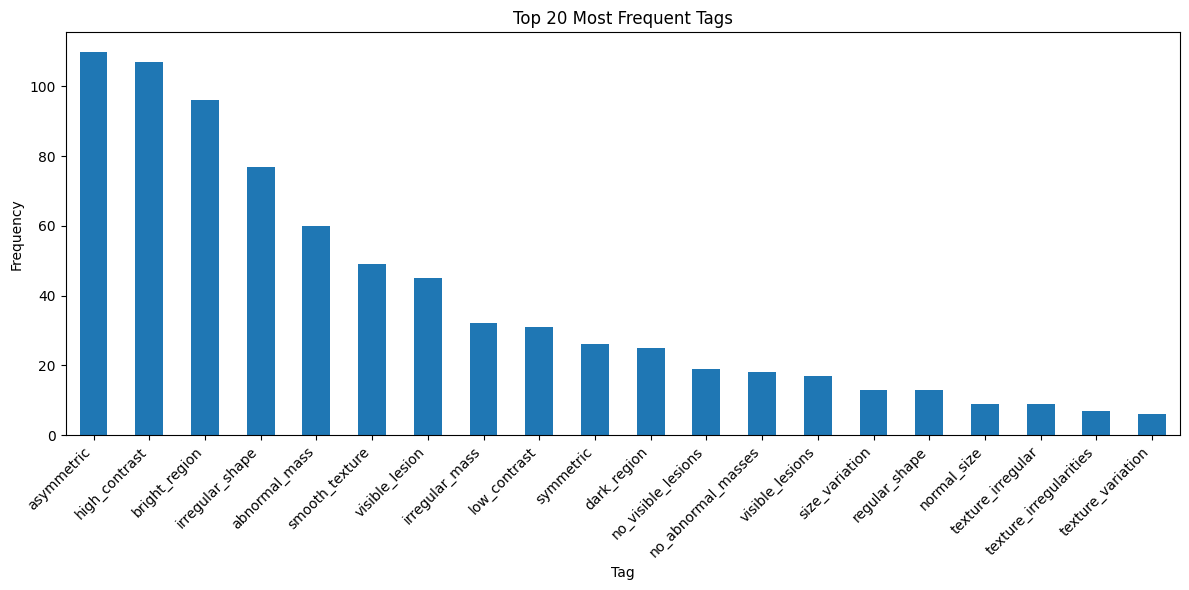


Tag frequency statistics:
count     86.000000
mean      10.395349
std       22.392898
min        1.000000
25%        1.000000
50%        2.000000
75%        5.000000
max      110.000000
dtype: float64


In [11]:
# Analyze tag frequencies
tag_counts = tabular_df[all_tags].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
tag_counts.head(20).plot(kind='bar')
plt.title('Top 20 Most Frequent Tags')
plt.xlabel('Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"\nTag frequency statistics:")
print(tag_counts.describe())

In [12]:
# Analyze which tags correlate most with tumor presence
tumor_correlation = {}
for tag in all_tags:
    # Only consider tags that appear in at least 5 images
    if tabular_df[tag].sum() >= 5:
        tumor_correlation[tag] = tabular_df[tag].astype(int).corr(tabular_df['label'])

tumor_corr_sorted = sorted(tumor_correlation.items(), key=lambda x: abs(x[1]), reverse=True)

print("\nTags most correlated with tumor presence:")
for tag, corr in tumor_corr_sorted[:15]:
    print(f"{tag}: {corr:.3f}")


Tags most correlated with tumor presence:
asymmetric: 0.503
high_contrast: 0.469
irregular_shape: 0.457
abnormal_mass: 0.426
visible_lesion: 0.328
bright_region: 0.322
symmetric: -0.294
no_visible_lesions: -0.237
irregular_mass: 0.230
regular_shape: -0.221
low_contrast: -0.199
normal_size: -0.199
no_abnormal_masses: -0.192
smooth_texture: -0.166
texture_irregular: 0.153


## 5. Define Predicates and Rules (train_ltn.py style)

Following the structure from `train_ltn.py`, we define:

1. **Simple Predicates**: Boolean checks on tag columns (no normalization needed - already 0/1)
2. **Image Feature Predicates**: Threshold checks on continuous features (normalized)
3. **Target Predicates**: `has_tumor(x)` and `no_has_tumor(x)` using the neural network `f`
4. **Parsed Rules**: Knowledge axioms in the form `Forall(x, Implies(premise, conclusion))`

In [13]:
# =============================================================================
# STEP 1: Define helper function for normalization (only for continuous features)
# =============================================================================

def normalize_value(X_train, feature_index, threshold):
    """Normalize a threshold value based on training data statistics."""
    feature_column = X_train[:, feature_index]
    mean = np.mean(feature_column)
    std = np.std(feature_column)
    if std == 0:
        return 0.0
    return (threshold - mean) / std


# =============================================================================
# STEP 2: Identify column indices for features
# =============================================================================

def get_tag_index(tag_name):
    """Get the column index for a tag in the feature matrix."""
    if tag_name in all_tags:
        return all_tags.index(tag_name)
    return None

def get_feature_index(feature_name):
    """Get the column index for an image feature in the feature matrix."""
    if feature_name in all_feature_cols:
        return all_feature_cols.index(feature_name)
    return None

# Tag indices (used by decision tree rules)
TAG_ASYMMETRIC = get_tag_index('asymmetric')
TAG_SYMMETRIC = get_tag_index('symmetric')

# Continuous feature indices (used by decision tree rules)
IDX_GLCM_ENERGY_90 = get_feature_index('glcm_energy_90')
IDX_GLCM_CONTRAST_90 = get_feature_index('glcm_contrast_90')
IDX_GLCM_CORRELATION_0 = get_feature_index('glcm_correlation_0')
IDX_GLCM_CORRELATION_45 = get_feature_index('glcm_correlation_45')
IDX_STAT_KURTOSIS = get_feature_index('stat_kurtosis')

print('Tag indices:')
print(f'  asymmetric: {TAG_ASYMMETRIC}')
print(f'  symmetric: {TAG_SYMMETRIC}')
print()
print('Continuous feature indices (from decision tree):')
print(f'  glcm_energy_90: {IDX_GLCM_ENERGY_90}')
print(f'  glcm_contrast_90: {IDX_GLCM_CONTRAST_90}')
print(f'  glcm_correlation_0: {IDX_GLCM_CORRELATION_0}')
print(f'  glcm_correlation_45: {IDX_GLCM_CORRELATION_45}')
print(f'  stat_kurtosis: {IDX_STAT_KURTOSIS}')


Tag indices:
  asymmetric: 7
  symmetric: 73

Continuous feature indices (from decision tree):
  glcm_energy_90: 97
  glcm_contrast_90: 89
  glcm_correlation_0: 90
  glcm_correlation_45: 92
  stat_kurtosis: 102


In [14]:
# =============================================================================
# STEP 3: Define LTN Fuzzy Logic Operators (same as train_ltn.py)
# =============================================================================

Not = ltn.Wrapper_Connective(ltn.fuzzy_ops.Not_Std())           # Not(x) = 1 - x
And = ltn.Wrapper_Connective(ltn.fuzzy_ops.And_Prod())          # And(a,b) = a * b
Or = ltn.Wrapper_Connective(ltn.fuzzy_ops.Or_ProbSum())         # Or(a,b) = a + b - a*b
Implies = ltn.Wrapper_Connective(ltn.fuzzy_ops.Implies_Reichenbach())  # Implies(a,b) = 1 - a + a*b
Forall = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMeanError(p=2), semantics="forall")
Exists = ltn.Wrapper_Quantifier(ltn.fuzzy_ops.Aggreg_pMean(p=2), semantics="exists")

formula_aggregator = ltn.Wrapper_Formula_Aggregator(ltn.fuzzy_ops.Aggreg_pMeanError(p=2))

print("LTN operators defined:")
print("  - Not (standard negation)")
print("  - And (product t-norm)")
print("  - Or (probabilistic sum)")
print("  - Implies (Reichenbach implication)")
print("  - Forall (p-mean error aggregation)")
print("  - Exists (p-mean aggregation)")

LTN operators defined:
  - Not (standard negation)
  - And (product t-norm)
  - Or (probabilistic sum)
  - Implies (Reichenbach implication)
  - Forall (p-mean error aggregation)
  - Exists (p-mean aggregation)


In [15]:
# =============================================================================
# STEP 4: Define Predicates (from decision tree rules)
# =============================================================================
# Only the two highest-purity decision tree rules are kept:
#   Rule 1 (no_tumor, 100%/100%): uses energy_90, asymmetric, contrast_90, correlation_0
#   Rule 3 (tumor, 92%/84%):      uses energy_90, symmetric, correlation_45, kurtosis

# --- Tag predicates ---
asymmetric = ltn.Predicate(lambda x: tf.cast(x[:, TAG_ASYMMETRIC] > 0.5, tf.float32))
symmetric = ltn.Predicate(lambda x: tf.cast(x[:, TAG_SYMMETRIC] > 0.5, tf.float32))

# --- Continuous feature predicates (thresholds from decision tree) ---
# Rule 1
high_glcm_energy_90 = ltn.Predicate(lambda x: tf.cast(x[:, IDX_GLCM_ENERGY_90] > 0.1779, tf.float32))
low_glcm_contrast_90 = ltn.Predicate(lambda x: tf.cast(x[:, IDX_GLCM_CONTRAST_90] <= 3.0991, tf.float32))
low_glcm_correlation_0 = ltn.Predicate(lambda x: tf.cast(x[:, IDX_GLCM_CORRELATION_0] <= 0.8938, tf.float32))
# Rule 3
low_glcm_energy_90 = ltn.Predicate(lambda x: tf.cast(x[:, IDX_GLCM_ENERGY_90] <= 0.1779, tf.float32))
high_glcm_correlation_45 = ltn.Predicate(lambda x: tf.cast(x[:, IDX_GLCM_CORRELATION_45] > 0.7297, tf.float32))
high_stat_kurtosis = ltn.Predicate(lambda x: tf.cast(x[:, IDX_STAT_KURTOSIS] > -1.3723, tf.float32))

print('Predicates defined (pruned to 2 high-purity rules):')
print('  Tag-based: asymmetric, symmetric')
print('  Rule 1: high_glcm_energy_90, low_glcm_contrast_90, low_glcm_correlation_0')
print('  Rule 3: low_glcm_energy_90, high_glcm_correlation_45, high_stat_kurtosis')


Predicates defined (pruned to 2 high-purity rules):
  Tag-based: asymmetric, symmetric
  Rule 1: high_glcm_energy_90, low_glcm_contrast_90, low_glcm_correlation_0
  Rule 3: low_glcm_energy_90, high_glcm_correlation_45, high_stat_kurtosis


## 6. Neural Network and Target Predicates

The neural network `f` is the learnable component. Target predicates connect labels to `f(x)`.

In [16]:
# =============================================================================
# STEP 5: Prepare Data
# =============================================================================

# Prepare data for LTN - using ALL features (tags + image features)
X = tabular_df[all_feature_cols].values.astype(np.float32)
y = tabular_df['label'].values.astype(bool)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Number of features: {X_train.shape[1]} (tags: {len(all_tags)}, image: {len(image_feature_names)})")

Training set: 175 samples
Test set: 76 samples
Number of features: 106 (tags: 86, image: 20)


## 5.1 RULES_ONLY Model (like lambda_gen_utils.py + create_rules_only.py)

This model uses pure Python lambda functions to evaluate rules - no neural network training.
The rules are evaluated in order, and the first matching rule determines the prediction.

In [17]:
# =============================================================================
# RULES_ONLY MODEL (pruned decision tree rules - highest purity only)
# =============================================================================
# Only 2 rules kept (1 per class) for highest purity:
#   Rule 1 (no_tumor): 100% train purity, 100% test purity
#   Rule 3 (tumor):     92% train purity,  84% test purity

import random

# Boolean operators
def PyAnd(a, b): return a and b
def PyOr(a, b): return a or b
def PyNot(a): return not a

# Python lambda predicates
py_asymmetric = lambda x: x[TAG_ASYMMETRIC] > 0.5
py_symmetric = lambda x: x[TAG_SYMMETRIC] > 0.5
py_high_glcm_energy_90 = lambda x: x[IDX_GLCM_ENERGY_90] > 0.1779
py_low_glcm_energy_90 = lambda x: x[IDX_GLCM_ENERGY_90] <= 0.1779
py_low_glcm_contrast_90 = lambda x: x[IDX_GLCM_CONTRAST_90] <= 3.0991
py_low_glcm_correlation_0 = lambda x: x[IDX_GLCM_CORRELATION_0] <= 0.8938
py_high_glcm_correlation_45 = lambda x: x[IDX_GLCM_CORRELATION_45] > 0.7297
py_high_stat_kurtosis = lambda x: x[IDX_STAT_KURTOSIS] > -1.3723

# Target predicates
py_has_tumor = lambda x, y: 1
py_no_has_tumor = lambda x, y: 0

# Parsed rules (2 high-purity rules)
parsed_rules_python = lambda x, y: [
    # RULE 1 (no_tumor, 100%/100%): high energy, not asymmetric, low contrast_90, low correlation_0
    (PyAnd(PyAnd(PyAnd(py_high_glcm_energy_90(x), PyNot(py_asymmetric(x))),
                 py_low_glcm_contrast_90(x)), py_low_glcm_correlation_0(x)),
     py_no_has_tumor(x, y)),

    # RULE 3 (tumor, 92%/84%): low energy, not symmetric, high correlation_45, high kurtosis
    (PyAnd(PyAnd(PyAnd(py_low_glcm_energy_90(x), PyNot(py_symmetric(x))),
                 py_high_glcm_correlation_45(x)), py_high_stat_kurtosis(x)),
     py_has_tumor(x, y)),
]

# Prediction function
def rules_only_predict(X, Y):
    preds = []
    for x, y in zip(X, Y):
        evaluated_rules = parsed_rules_python(x, y)
        catch_all_rule = (True, random.choice([0, 1]))
        evaluated_rules.append(catch_all_rule)
        for rule_premise, rule_result in evaluated_rules:
            if rule_premise:
                preds.append(rule_result)
                break
    return np.array(preds)


def get_satisfied_rule_indexes(x, y):
    indexes = []
    evaluated_rules = parsed_rules_python(x, y)
    for idx, (rule_premise, _) in enumerate(evaluated_rules):
        if rule_premise:
            indexes.append(idx)
    return np.array(indexes)


print('RULES_ONLY model defined with 2 high-purity rules:')
print('  Rule 1: high_energy ∧ ¬asymmetric ∧ low_contrast_90 ∧ low_correlation_0 → no_tumor')
print('  Rule 3: low_energy ∧ ¬symmetric ∧ high_correlation_45 ∧ high_kurtosis → tumor')


RULES_ONLY model defined with 2 high-purity rules:
  Rule 1: high_energy ∧ ¬asymmetric ∧ low_contrast_90 ∧ low_correlation_0 → no_tumor
  Rule 3: low_energy ∧ ¬symmetric ∧ high_correlation_45 ∧ high_kurtosis → tumor


In [18]:
# =============================================================================
# STEP 6: Define Neural Network f and Target Predicates (like train_ltn.py)
# =============================================================================

# The neural network predicate - this is what we're training
f = ltn.Predicate.MLP([(X_train.shape[1],)], hidden_layer_sizes=(16, 16))

# -----------------------------------------------------------------------------
# Target Predicates (exactly like in train_ltn.py predicates.txt)
# These connect the ground truth labels to the neural network output
# -----------------------------------------------------------------------------

# has_tumor: for positive samples, f(x) should output high value
has_tumor = lambda x, y: f(x)

# no_has_tumor: for negative samples, f(x) should output low value (Not(f(x)) high)
no_has_tumor = lambda x, y: Not(f(x))

# Aliases used in get_axioms (matching train_ltn.py convention)
target = has_tumor
no_target = no_has_tumor

print(f"Neural network f created with input size: {X_train.shape[1]}")
print("Target predicates defined:")
print("  - has_tumor(x, y) = f(x)")
print("  - no_has_tumor(x, y) = Not(f(x))")

Neural network f created with input size: 106
Target predicates defined:
  - has_tumor(x, y) = f(x)
  - no_has_tumor(x, y) = Not(f(x))


In [19]:
# =============================================================================
# STEP 7: Define Parsed Rules (pruned to highest-purity decision tree rules)
# =============================================================================
# Dropped Rule 2 (67% train purity) and Rule 4 (67% test purity) which were
# injecting noise into LTN optimization.

parsed_rules = lambda x, y: [
    # -------------------------------------------------------------------------
    # RULE 1 (no_tumor): high_glcm_energy_90 ∧ ¬asymmetric ∧ low_glcm_contrast_90
    #                    ∧ low_glcm_correlation_0 → no_has_tumor
    # Train: 29 samples, 100% purity | Test: 8/8 correct (100%)
    # -------------------------------------------------------------------------
    Forall(x, Implies(
        And(And(And(high_glcm_energy_90(x), Not(asymmetric(x))),
                low_glcm_contrast_90(x)), low_glcm_correlation_0(x)),
        Not(f(x))
    )),

    # -------------------------------------------------------------------------
    # RULE 3 (tumor): low_glcm_energy_90 ∧ ¬symmetric ∧ high_glcm_correlation_45
    #                 ∧ high_stat_kurtosis → has_tumor
    # Train: 106 samples, 92% purity | Test: 21/25 correct (84%)
    # -------------------------------------------------------------------------
    Forall(x, Implies(
        And(And(And(low_glcm_energy_90(x), Not(symmetric(x))),
                high_glcm_correlation_45(x)), high_stat_kurtosis(x)),
        f(x)
    )),
]

print('Parsed rules defined (2 high-purity axioms):')
print('  1. high_energy_90 ∧ ¬asymmetric ∧ low_contrast_90 ∧ low_correlation_0 → ¬has_tumor (100%/100%)')
print('  2. low_energy_90 ∧ ¬symmetric ∧ high_correlation_45 ∧ high_kurtosis → has_tumor (92%/84%)')


Parsed rules defined (2 high-purity axioms):
  1. high_energy_90 ∧ ¬asymmetric ∧ low_contrast_90 ∧ low_correlation_0 → ¬has_tumor (100%/100%)
  2. low_energy_90 ∧ ¬symmetric ∧ high_correlation_45 ∧ high_kurtosis → has_tumor (92%/84%)


In [20]:
# =============================================================================
# STEP 8: Define get_axioms Function (exactly like train_ltn.py)
# =============================================================================

def get_axioms(X_batch, y_batch, use_rules=True):
    """
    Create LTN axioms for training (same structure as train_ltn.py).
    
    Args:
        X_batch: Feature tensor for current batch
        y_batch: Label tensor for current batch
        use_rules: Whether to include knowledge-based rules
    
    Returns:
        List of axioms to be satisfied
    """
    # Create LTN variables
    x = ltn.Variable("x", X_batch)
    y = ltn.Variable("y", y_batch)
    
    # Split data by class (exactly like train_ltn.py)
    x_A = ltn.Variable("x_A", tf.boolean_mask(X_batch, y_batch))           # Positive class (tumor)
    x_not_A = ltn.Variable("x_not_A", tf.boolean_mask(X_batch, tf.logical_not(y_batch)))  # Negative class (no tumor)
    
    # -------------------------------------------------------------------------
    # BASE AXIOMS: Supervised learning constraints
    # These encode the ground truth labels
    # -------------------------------------------------------------------------
    base_axioms = [
        Forall(x_A, target(x_A, f(x_A))),           # ∀x ∈ tumor: f(x) should be high
        Forall(x_not_A, no_target(x_not_A, f(x_not_A)))  # ∀x ∈ healthy: f(x) should be low
    ]
    
    axioms = base_axioms
    
    # -------------------------------------------------------------------------
    # KNOWLEDGE AXIOMS: Domain rules (if enabled)
    # These are loaded from parsed_rules (like exec(rules_from_file) in train_ltn.py)
    # -------------------------------------------------------------------------
    if use_rules:
        axioms = base_axioms + parsed_rules(x, y)
    
    return axioms


print("get_axioms function defined")
print("  - Base axioms: 2 (supervised constraints)")
print("  - Knowledge axioms: 2 (high-purity decision tree rules)")
print("  - Total when use_rules=True: 4 axioms")

get_axioms function defined
  - Base axioms: 2 (supervised constraints)
  - Knowledge axioms: 2 (high-purity decision tree rules)
  - Total when use_rules=True: 4 axioms


In [21]:
# =============================================================================
# STEP 9: Training Loop - Train BOTH MLP and LTN Models (with Early Stopping)
# =============================================================================

from sklearn.metrics import balanced_accuracy_score

def create_and_train_model(X_train, y_train, X_test, y_test, 
                           use_rules, max_epochs=1000, learning_rate=0.001,
                           patience=50, min_delta=1e-5,
                           model_name="Model"):
    """
    Create and train a new LTN model until convergence (loss plateau).
    Saves and restores the best model based on validation balanced accuracy.
    
    Args:
        use_rules: False for MLP (base axioms only), True for LTN (base + knowledge rules)
        max_epochs: Maximum number of epochs (safety limit)
        learning_rate: Adam optimizer learning rate
        patience: Number of epochs to wait for improvement before stopping
        min_delta: Minimum change in loss to qualify as an improvement
        model_name: Name for logging
    
    Returns:
        Trained model f (with best weights), training history, final epoch count
    """
    # Create fresh neural network for this model
    f_model = ltn.Predicate.MLP([(X_train.shape[1],)], hidden_layer_sizes=(16, 16))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    # Training tracking
    train_losses = []
    val_losses = []
    val_balanced_accs = []
    
    # Early stopping tracking (based on training loss plateau)
    best_loss = float('inf')
    epochs_without_improvement = 0
    best_loss_epoch = 0
    
    # Best model tracking (based on validation balanced accuracy)
    best_val_balanced_acc = 0.0
    best_val_acc_epoch = 0
    best_weights = None
    
    print(f"\n{'='*60}")
    print(f"Training {model_name} (use_rules={use_rules})")
    print(f"Early stopping: patience={patience}, min_delta={min_delta}")
    print(f"Best model: saved based on validation balanced accuracy")
    print(f"{'='*60}")
    
    for epoch in range(max_epochs):
        with tf.GradientTape() as tape:
            # Create axioms - need to redefine target predicates with this model's f
            x = ltn.Variable("x", X_train)
            y = ltn.Variable("y", y_train)
            x_A = ltn.Variable("x_A", tf.boolean_mask(X_train, y_train))
            x_not_A = ltn.Variable("x_not_A", tf.boolean_mask(X_train, tf.logical_not(y_train)))
            
            # Base axioms
            base_axioms = [
                Forall(x_A, f_model(x_A)),
                Forall(x_not_A, Not(f_model(x_not_A)))
            ]
            
            axioms = base_axioms
            
            # Add knowledge rules if use_rules=True
            if use_rules:
                knowledge_axioms = [
                    # Rule 1 (no_tumor, 100%/100%): high_energy ∧ ¬asymmetric ∧ low_contrast_90 ∧ low_correlation_0
                    Forall(x, Implies(
                        And(And(And(high_glcm_energy_90(x), Not(asymmetric(x))),
                                low_glcm_contrast_90(x)), low_glcm_correlation_0(x)),
                        Not(f_model(x)))),
                    # Rule 3 (tumor, 92%/84%): low_energy ∧ ¬symmetric ∧ high_correlation_45 ∧ high_kurtosis
                    Forall(x, Implies(
                        And(And(And(low_glcm_energy_90(x), Not(symmetric(x))),
                                high_glcm_correlation_45(x)), high_stat_kurtosis(x)),
                        f_model(x))),
                ]
                axioms = base_axioms + knowledge_axioms
            
            sat_level = formula_aggregator(axioms).tensor
            loss = 1.0 - sat_level
        
        gradients = tape.gradient(loss, f_model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, f_model.trainable_variables))
        train_loss = loss.numpy()
        train_losses.append(train_loss)
        
        # Validation loss
        x_val = ltn.Variable("x_val", X_test)
        x_A_val = ltn.Variable("x_A_val", tf.boolean_mask(X_test, y_test))
        x_not_A_val = ltn.Variable("x_not_A_val", tf.boolean_mask(X_test, tf.logical_not(y_test)))
        
        val_base_axioms = [
            Forall(x_A_val, f_model(x_A_val)),
            Forall(x_not_A_val, Not(f_model(x_not_A_val)))
        ]
        val_axioms = val_base_axioms
        if use_rules:
            val_knowledge_axioms = [
                Forall(x_val, Implies(
                    And(And(And(high_glcm_energy_90(x_val), Not(asymmetric(x_val))),
                            low_glcm_contrast_90(x_val)), low_glcm_correlation_0(x_val)),
                    Not(f_model(x_val)))),
                Forall(x_val, Implies(
                    And(And(And(low_glcm_energy_90(x_val), Not(symmetric(x_val))),
                            high_glcm_correlation_45(x_val)), high_stat_kurtosis(x_val)),
                    f_model(x_val))),
            ]
            val_axioms = val_base_axioms + val_knowledge_axioms
        
        val_sat = formula_aggregator(val_axioms).tensor
        val_loss = 1.0 - val_sat
        val_losses.append(val_loss.numpy())
        
        # Compute validation balanced accuracy
        val_preds = f_model.model(X_test).numpy()
        val_preds_binary = (val_preds > 0.5).astype(int).flatten()
        val_balanced_acc = balanced_accuracy_score(y_test.astype(int), val_preds_binary)
        val_balanced_accs.append(val_balanced_acc)
        
        # Save best model based on validation balanced accuracy
        if val_balanced_acc > best_val_balanced_acc:
            best_val_balanced_acc = val_balanced_acc
            best_val_acc_epoch = epoch + 1
            # Save weights (deep copy)
            best_weights = [w.numpy().copy() for w in f_model.trainable_variables]
        
        # Early stopping check (based on training loss plateau)
        if train_loss < best_loss - min_delta:
            best_loss = train_loss
            best_loss_epoch = epoch + 1
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        # Print progress every 50 epochs or when stopping
        if (epoch + 1) % 50 == 0:
            print(f"Epoch [{epoch+1}] - Train Loss: {train_loss:.4f}, Val Loss: {val_loss.numpy():.4f}, "
                  f"Val BalAcc: {val_balanced_acc:.4f}, Best BalAcc: {best_val_balanced_acc:.4f} (ep {best_val_acc_epoch})")
        
        # Check if we should stop
        if epochs_without_improvement >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}! No improvement for {patience} epochs.")
            print(f"Best training loss: {best_loss:.4f} at epoch {best_loss_epoch}")
            break
    
    final_epoch = epoch + 1
    if final_epoch == max_epochs:
        print(f"\nReached max_epochs ({max_epochs}). Consider increasing max_epochs.")
    
    # Restore best weights based on validation balanced accuracy
    if best_weights is not None:
        print(f"\nRestoring best model from epoch {best_val_acc_epoch} (Val BalAcc: {best_val_balanced_acc:.4f})")
        for var, weight in zip(f_model.trainable_variables, best_weights):
            var.assign(weight)
    
    print(f"Final epoch: {final_epoch}, Best Val BalAcc epoch: {best_val_acc_epoch}")
    print(f"Best Val Balanced Accuracy: {best_val_balanced_acc:.4f}")
    
    history = {
        'train_loss': train_losses, 
        'val_loss': val_losses,
        'val_balanced_acc': val_balanced_accs,
        'best_epoch': best_val_acc_epoch,
        'best_val_balanced_acc': best_val_balanced_acc
    }
    
    return f_model, history, final_epoch


# =============================================================================
# Train both MLP and LTN models until convergence
# =============================================================================

# Train MLP (base axioms only - use_rules=False)
mlp_model, mlp_history, mlp_epochs = create_and_train_model(
    X_train, y_train, X_test, y_test,
    use_rules=False, max_epochs=100, patience=50, min_delta=1e-5, model_name="MLP"
)

# Train LTN (base axioms + knowledge rules - use_rules=True)
ltn_model, ltn_history, ltn_epochs = create_and_train_model(
    X_train, y_train, X_test, y_test,
    use_rules=True, max_epochs=100, patience=50, min_delta=1e-5, model_name="LTN"
)

print("\n" + "="*60)
print("Training completed for both MLP and LTN models!")
print(f"MLP: converged in {mlp_epochs} epochs, best at epoch {mlp_history['best_epoch']} (BalAcc: {mlp_history['best_val_balanced_acc']:.4f})")
print(f"LTN: converged in {ltn_epochs} epochs, best at epoch {ltn_history['best_epoch']} (BalAcc: {ltn_history['best_val_balanced_acc']:.4f})")
print("="*60)


Training MLP (use_rules=False)
Early stopping: patience=50, min_delta=1e-05
Best model: saved based on validation balanced accuracy
Epoch [50] - Train Loss: 0.3901, Val Loss: 0.3659, Val BalAcc: 0.8485, Best BalAcc: 0.8591 (ep 43)
Epoch [100] - Train Loss: 0.3425, Val Loss: 0.3478, Val BalAcc: 0.8632, Best BalAcc: 0.8632 (ep 93)

Reached max_epochs (100). Consider increasing max_epochs.

Restoring best model from epoch 93 (Val BalAcc: 0.8632)
Final epoch: 100, Best Val BalAcc epoch: 93
Best Val Balanced Accuracy: 0.8632

Training LTN (use_rules=True)
Early stopping: patience=50, min_delta=1e-05
Best model: saved based on validation balanced accuracy
Epoch [50] - Train Loss: 0.3321, Val Loss: 0.3145, Val BalAcc: 0.7982, Best BalAcc: 0.8195 (ep 49)
Epoch [100] - Train Loss: 0.2863, Val Loss: 0.2688, Val BalAcc: 0.8672, Best BalAcc: 0.8672 (ep 98)

Reached max_epochs (100). Consider increasing max_epochs.

Restoring best model from epoch 98 (Val BalAcc: 0.8672)
Final epoch: 100, Best Val

## 7. Evaluation

Now we evaluate the trained model using the neural network `f`.

In [22]:
# =============================================================================
# STEP 10: Model Comparison - RULES_ONLY vs MLP vs LTN
# =============================================================================

from sklearn.metrics import balanced_accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

def evaluate_model(model_func, X, y, model_name):
    """
    Evaluate a model and return metrics.
    
    Args:
        model_func: Function that takes (X, y) and returns predictions
        X: Input features
        y: True labels
        model_name: Name for display
    
    Returns:
        Dictionary of metrics
    """
    preds = model_func(X, y)
    
    # Ensure predictions are binary
    if isinstance(preds, np.ndarray) and preds.dtype == np.float32:
        preds_binary = (preds > 0.5).astype(int).flatten()
    else:
        preds_binary = np.array(preds).astype(int).flatten()
    
    y_true = np.array(y).astype(int).flatten()
    
    metrics = {
        'Accuracy': accuracy_score(y_true, preds_binary),
        'Balanced Accuracy': balanced_accuracy_score(y_true, preds_binary),
        'Precision': precision_score(y_true, preds_binary, zero_division=0),
        'Recall': recall_score(y_true, preds_binary, zero_division=0),
        'F1 Score': f1_score(y_true, preds_binary, zero_division=0),
    }
    
    return metrics, preds_binary


# =============================================================================
# Define prediction functions for each model
# =============================================================================

def rules_only_func(X, y):
    """RULES_ONLY: Pure Python rule-based prediction."""
    return rules_only_predict(X, y)

def mlp_func(X, y):
    """MLP: Neural network trained with base axioms only."""
    return mlp_model.model(X).numpy()

def ltn_func(X, y):
    """LTN: Neural network trained with base axioms + knowledge rules."""
    return ltn_model.model(X).numpy()


# =============================================================================
# Evaluate all models on test set
# =============================================================================

print("=" * 70)
print("MODEL COMPARISON - TEST SET RESULTS")
print("=" * 70)

models = {
    'RULES_ONLY': rules_only_func,
    'MLP': mlp_func,
    'LTN': ltn_func
}

results = {}
predictions = {}

for model_name, model_func in models.items():
    metrics, preds = evaluate_model(model_func, X_test, y_test, model_name)
    results[model_name] = metrics
    predictions[model_name] = preds

# =============================================================================
# Display comparison table
# =============================================================================

# Create comparison DataFrame
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)

print("\nMetrics Comparison:")
print("-" * 70)
print(comparison_df.to_string())
print("-" * 70)

# =============================================================================
# Highlight best model for each metric
# =============================================================================

print("\nBest Model per Metric:")
for metric in comparison_df.columns:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"  {metric}: {best_model} ({best_value:.4f})")

# =============================================================================
# Improvement analysis: LTN vs MLP vs RULES_ONLY
# =============================================================================

print("\n" + "=" * 70)
print("IMPROVEMENT ANALYSIS")
print("=" * 70)

rules_acc = results['RULES_ONLY']['Accuracy']
mlp_acc = results['MLP']['Accuracy']
ltn_acc = results['LTN']['Accuracy']

print(f"\nAccuracy:")
print(f"  RULES_ONLY: {rules_acc:.4f}")
print(f"  MLP:        {mlp_acc:.4f} ({((mlp_acc - rules_acc) / rules_acc * 100):+.2f}% vs RULES_ONLY)")
print(f"  LTN:        {ltn_acc:.4f} ({((ltn_acc - mlp_acc) / mlp_acc * 100):+.2f}% vs MLP)")

rules_f1 = results['RULES_ONLY']['F1 Score']
mlp_f1 = results['MLP']['F1 Score']
ltn_f1 = results['LTN']['F1 Score']

print(f"\nF1 Score:")
print(f"  RULES_ONLY: {rules_f1:.4f}")
print(f"  MLP:        {mlp_f1:.4f} ({((mlp_f1 - rules_f1) / max(rules_f1, 0.0001) * 100):+.2f}% vs RULES_ONLY)")
print(f"  LTN:        {ltn_f1:.4f} ({((ltn_f1 - mlp_f1) / max(mlp_f1, 0.0001) * 100):+.2f}% vs MLP)")

MODEL COMPARISON - TEST SET RESULTS

Metrics Comparison:
----------------------------------------------------------------------
            Accuracy  Balanced Accuracy  Precision  Recall  F1 Score
RULES_ONLY    0.7632             0.7491     0.8085  0.8085    0.8085
MLP           0.8553             0.8632     0.9286  0.8298    0.8764
LTN           0.8684             0.8672     0.9111  0.8723    0.8913
----------------------------------------------------------------------

Best Model per Metric:
  Accuracy: LTN (0.8684)
  Balanced Accuracy: LTN (0.8672)
  Precision: MLP (0.9286)
  Recall: LTN (0.8723)
  F1 Score: LTN (0.8913)

IMPROVEMENT ANALYSIS

Accuracy:
  RULES_ONLY: 0.7632
  MLP:        0.8553 (+12.07% vs RULES_ONLY)
  LTN:        0.8684 (+1.54% vs MLP)

F1 Score:
  RULES_ONLY: 0.8085
  MLP:        0.8764 (+8.40% vs RULES_ONLY)
  LTN:        0.8913 (+1.70% vs MLP)


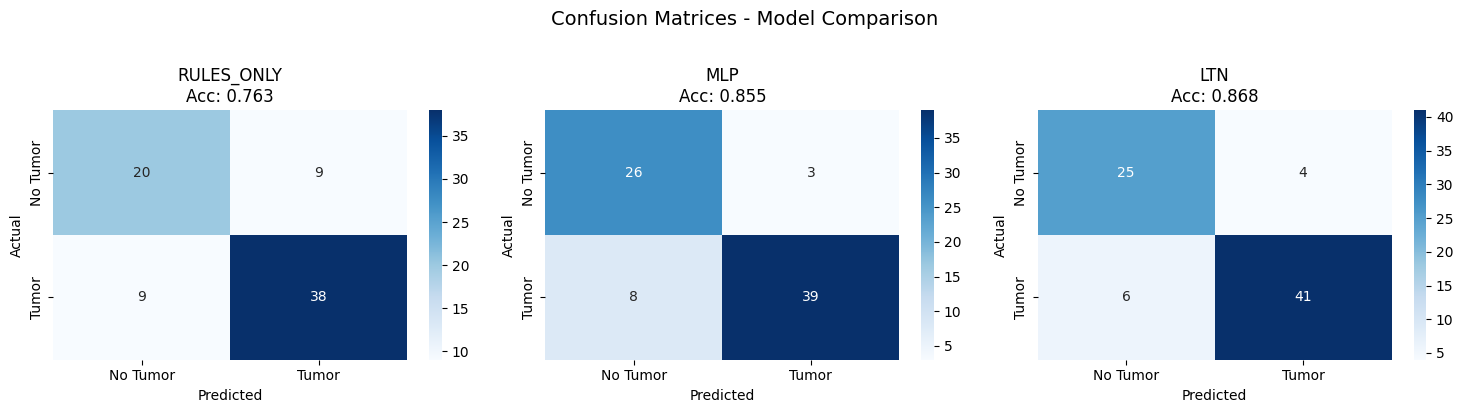

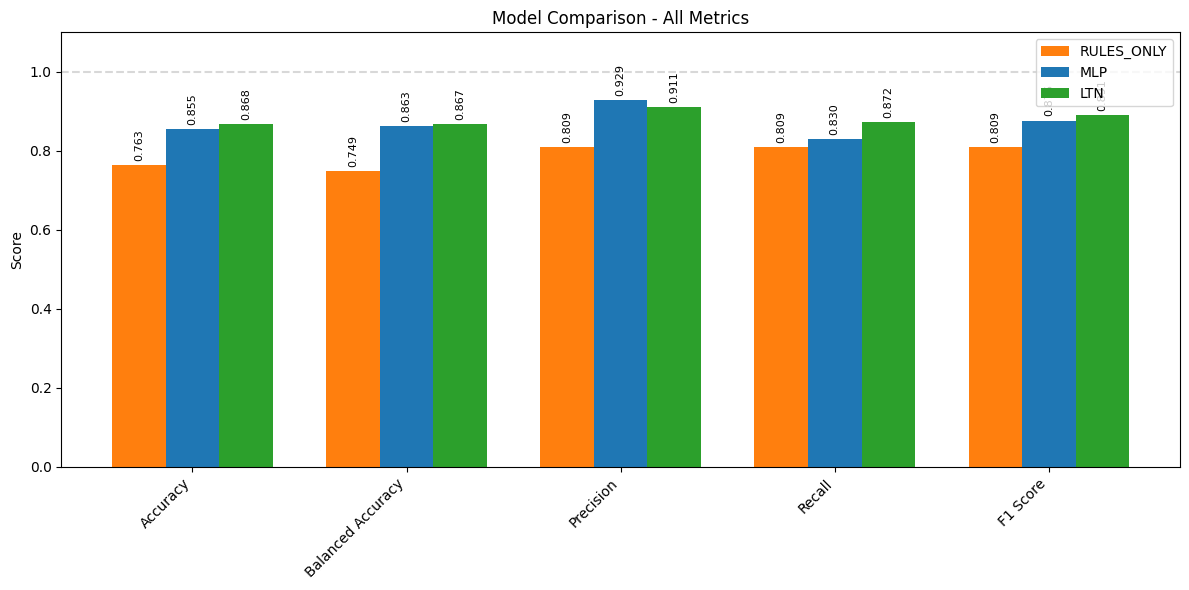

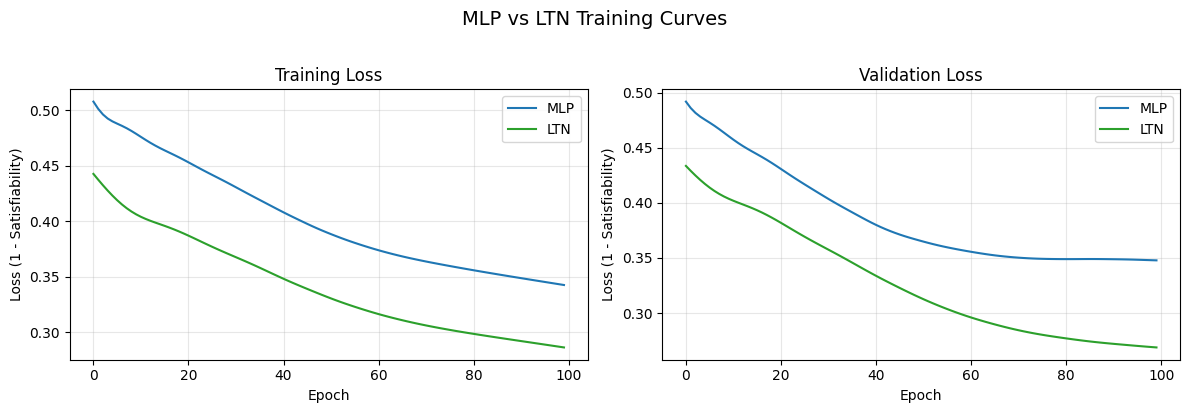

In [23]:
# =============================================================================
# STEP 11: Visualization - Confusion Matrices and Bar Chart
# =============================================================================

# Confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, (model_name, preds) in enumerate(predictions.items()):
    ax = axes[idx]
    cm = confusion_matrix(y_test.astype(int), preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Tumor', 'Tumor'],
                yticklabels=['No Tumor', 'Tumor'])
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{model_name}\nAcc: {results[model_name]["Accuracy"]:.3f}')

plt.suptitle('Confusion Matrices - Model Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# =============================================================================
# Bar chart comparison
# =============================================================================

metrics_to_plot = ['Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, [results['RULES_ONLY'][m] for m in metrics_to_plot], 
               width, label='RULES_ONLY', color='#ff7f0e')
bars2 = ax.bar(x, [results['MLP'][m] for m in metrics_to_plot], 
               width, label='MLP', color='#1f77b4')
bars3 = ax.bar(x + width, [results['LTN'][m] for m in metrics_to_plot], 
               width, label='LTN', color='#2ca02c')

ax.set_ylabel('Score')
ax.set_title('Model Comparison - All Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 1.1)
ax.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# =============================================================================
# Training loss curves (MLP vs LTN)
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Training loss
ax = axes[0]
ax.plot(mlp_history['train_loss'], label='MLP', color='#1f77b4')
ax.plot(ltn_history['train_loss'], label='LTN', color='#2ca02c')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (1 - Satisfiability)')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# Validation loss
ax = axes[1]
ax.plot(mlp_history['val_loss'], label='MLP', color='#1f77b4')
ax.plot(ltn_history['val_loss'], label='LTN', color='#2ca02c')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss (1 - Satisfiability)')
ax.set_title('Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle('MLP vs LTN Training Curves', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# =============================================================================
# Summary: Structure following train_ltn.py
# =============================================================================

print('=' * 70)
print('STRUCTURE SUMMARY (following train_ltn.py pattern)')
print('=' * 70)

print('\n1. PREDICATES (from decision tree, pruned to high-purity rules):')
print('   Tag-based (boolean):')
print('     - asymmetric, symmetric')
print('   Continuous (decision tree thresholds):')
print('     - high/low_glcm_energy_90 (threshold: 0.1779)')
print('     - low_glcm_contrast_90 (threshold: 3.0991)')
print('     - low_glcm_correlation_0 (threshold: 0.8938)')
print('     - high_glcm_correlation_45 (threshold: 0.7297)')
print('     - high_stat_kurtosis (threshold: -1.3723)')

print(f'\n2. NEURAL NETWORK:')
print(f'   f = ltn.Predicate.MLP([({X_train.shape[1]},)], hidden_layer_sizes=(16, 16))')

print('\n3. TARGET PREDICATES:')
print('   has_tumor = λ(x, y): f(x)')
print('   no_has_tumor = λ(x, y): Not(f(x))')

print('\n4. PARSED RULES (2 high-purity decision tree rules):')
print('   parsed_rules = λ(x, y): [')
print('     Forall(x, Implies(high_energy ∧ ¬asymm ∧ low_contrast_90 ∧ low_corr_0, ¬tumor))  [100%/100%]')
print('     Forall(x, Implies(low_energy ∧ ¬symmetric ∧ high_corr_45 ∧ high_kurt, tumor))     [92%/84%]')
print('   ]')

print('\n5. GET_AXIOMS FUNCTION:')
print('   base_axioms (2) + knowledge_axioms (2) = 4 total')

print('\n6. LOSS FUNCTION:')
print('   sat_level = formula_aggregator(axioms)')
print('   loss = 1.0 - sat_level')

print('\n' + '=' * 70)


STRUCTURE SUMMARY (following train_ltn.py pattern)

1. PREDICATES (from decision tree, pruned to high-purity rules):
   Tag-based (boolean):
     - asymmetric, symmetric
   Continuous (decision tree thresholds):
     - high/low_glcm_energy_90 (threshold: 0.1779)
     - low_glcm_contrast_90 (threshold: 3.0991)
     - low_glcm_correlation_0 (threshold: 0.8938)
     - high_glcm_correlation_45 (threshold: 0.7297)
     - high_stat_kurtosis (threshold: -1.3723)

2. NEURAL NETWORK:
   f = ltn.Predicate.MLP([(106,)], hidden_layer_sizes=(16, 16))

3. TARGET PREDICATES:
   has_tumor = λ(x, y): f(x)
   no_has_tumor = λ(x, y): Not(f(x))

4. PARSED RULES (2 high-purity decision tree rules):
   parsed_rules = λ(x, y): [
     Forall(x, Implies(high_energy ∧ ¬asymm ∧ low_contrast_90 ∧ low_corr_0, ¬tumor))  [100%/100%]
     Forall(x, Implies(low_energy ∧ ¬symmetric ∧ high_corr_45 ∧ high_kurt, tumor))     [92%/84%]
   ]

5. GET_AXIOMS FUNCTION:
   base_axioms (2) + knowledge_axioms (2) = 4 total

6. LOS